In [1]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# import matplotlib.pyplot as plt
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] =False

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm
from google.colab import drive

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False


# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"
df_raw = pd.read_csv(PATH + "train_heat.csv")
df_temp = pd.read_csv(PATH +"test_heat.csv")

Mounted at /content/drive


In [3]:
df_temp

,TM,branch_ID,TA,WD,WS,RN_DAY,RN_HR1,HM,SI,ta_chi,heat_demand
0,2024010100,A,0.5,171.3,0.8,2.5,0.0,97.1,-99.0,0.3,NaN
1,2024010101,A,0.4,93.7,1.0,0.0,0.0,96.8,-99.0,0.1,NaN
2,2024010102,A,-0.1,133.0,0.8,0.0,0.0,97.0,-99.0,0.0,NaN
3,2024010103,A,-0.8,218.6,0.6,0.0,0.0,96.9,-99.0,-0.2,NaN
4,2024010104,A,0.1,58.7,1.5,0.0,0.0,97.0,-99.0,-0.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
166910,2024123120,S,-1.1,360.0,0.0,0.0,0.0,45.8,-99.0,-1.7,NaN
166911,2024123121,S,-1.3,360.0,0.0,0.0,0.0,48.3,-99.0,-2.3,NaN
166912,2024123122,S,-2.4,360.0,0.0,0.0,0.0,60.0,-99.0,-3.1,NaN
166913,2024123123,S,-3.6,360.0,0.0,0.0,0.0,65.7,-99.0,-3.9,NaN


In [4]:
df_temp.columns

Index(['TM', 'branch_ID', 'TA', 'WD', 'WS', 'RN_DAY', 'RN_HR1', 'HM', 'SI',
       'ta_chi', 'heat_demand'],
      dtype='object')

In [5]:
# 이상치 처리
df = df_raw.copy()
df_test = df_temp.copy()

new_column_names_map = {
    'TM': 'tm',
    'branch_ID': 'branch_id', # ID는 소문자 id로 변경
    'TA': 'ta',
    'WD': 'wd',
    'WS': 'ws',
    'RN_DAY': 'rn_day',
    'RN_HR1': 'rn_hr1',
    'HM': 'hm',
    'SI': 'si',
    'ta_chi': 'ta_chi',
    'heat_demand': 'heat_demand'
}

df_test.rename(columns=new_column_names_map, inplace=True)

df.columns = [col.split('.')[1] for col in df.columns]
for col in df.columns:
    df[col] = np.where(df[col] == -99, np.nan, df[col])
df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

# 필요없는 컬럼 제거
df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

# 결측치 제거
df.dropna(inplace=True)

# 날짜 파싱 및 파생 변수 생성
df['tm'] = pd.to_datetime(df['tm'].astype(int), format='%Y%m%d%H')
df['month'] = df['tm'].dt.month
df['hour'] = df['tm'].dt.hour

# 요일 및 주말 여부
df['weekday'] = df['tm'].dt.dayofweek
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 계절성 변수 (1년 주기)
df['dayofyear'] = df['tm'].dt.dayofyear
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

df['date_index'] = (df['tm'] - df['tm'].min()).dt.days
# 더 이상 필요 없는 컬럼 제거
df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

In [6]:
df.sort_index(axis=1)


,branch_id,date_index,dayofyear_cos,dayofyear_sin,heat_demand,hm,hour,is_weekend,month,rn_day,ta,wd,ws
0,A,0,0.999852,1.721336e-02,281.0,68.2,1,0,1,0.0,-10.1,78.3,0.5
1,A,0,0.999852,1.721336e-02,262.0,69.9,2,0,1,0.0,-10.2,71.9,0.6
2,A,0,0.999852,1.721336e-02,266.0,69.2,3,0,1,0.0,-10.0,360.0,0.0
3,A,0,0.999852,1.721336e-02,285.0,65.0,4,0,1,0.0,-9.3,155.9,0.5
4,A,0,0.999852,1.721336e-02,283.0,63.5,5,0,1,0.0,-9.0,74.3,1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499296,S,1094,1.000000,6.432491e-16,34.0,91.5,19,1,12,2.5,3.2,233.5,0.4
499297,S,1094,1.000000,6.432491e-16,35.0,92.1,20,1,12,2.5,2.9,227.4,0.1
499298,S,1094,1.000000,6.432491e-16,35.0,93.3,21,1,12,2.5,2.1,360.0,0.0
499299,S,1094,1.000000,6.432491e-16,40.0,95.5,22,1,12,2.5,2.2,30.0,1.4


In [7]:
df_test.sort_index(axis=1)


,branch_id,heat_demand,hm,rn_day,rn_hr1,si,ta,ta_chi,tm,wd,ws
0,A,NaN,97.1,2.5,0.0,-99.0,0.5,0.3,2024010100,171.3,0.8
1,A,NaN,96.8,0.0,0.0,-99.0,0.4,0.1,2024010101,93.7,1.0
2,A,NaN,97.0,0.0,0.0,-99.0,-0.1,0.0,2024010102,133.0,0.8
3,A,NaN,96.9,0.0,0.0,-99.0,-0.8,-0.2,2024010103,218.6,0.6
4,A,NaN,97.0,0.0,0.0,-99.0,0.1,-0.1,2024010104,58.7,1.5
...,...,...,...,...,...,...,...,...,...,...,...
166910,S,NaN,45.8,0.0,0.0,-99.0,-1.1,-1.7,2024123120,360.0,0.0
166911,S,NaN,48.3,0.0,0.0,-99.0,-1.3,-2.3,2024123121,360.0,0.0
166912,S,NaN,60.0,0.0,0.0,-99.0,-2.4,-3.1,2024123122,360.0,0.0
166913,S,NaN,65.7,0.0,0.0,-99.0,-3.6,-3.9,2024123123,360.0,0.0


In [8]:
import pandas as pd
import numpy as np

# 2. 이상치 처리
# -99 값을 NaN으로 대체
for col in df_test.columns:
    df_test[col] = np.where(df_test[col] == -99, np.nan, df_test[col])
print("2. 이상치 (-99) 처리 완료")


df_test['wd'] = np.where(df_test['wd'] < 0, np.nan, df_test['wd'])

df_test.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

# 5. 날짜 파싱 및 파생 변수 생성
# 'tm' 컬럼을 datetime 객체로 변환하고 'month', 'hour'를 추출합니다.
df_test['tm'] = pd.to_datetime(df_test['tm'].astype(int), format='%Y%m%d%H')
df_test['month'] = df_test['tm'].dt.month
df_test['hour'] = df_test['tm'].dt.hour
print("5. 날짜 파싱 및 파생 변수 ('month', 'hour') 생성 완료")

# 6. 요일 및 주말 여부
# 'weekday' (요일)와 'is_weekend' (주말 여부) 컬럼을 생성합니다.
df_test['weekday'] = df_test['tm'].dt.dayofweek
df_test['is_weekend'] = df_test['weekday'].apply(lambda x: 1 if x >= 5 else 0)
print("6. 요일 및 주말 여부 ('weekday', 'is_weekend') 생성 완료")

# 7. 계절성 변수 (1년 주기)
# 'dayofyear', 'dayofyear_sin', 'dayofyear_cos' 컬럼을 생성합니다.
df_test['dayofyear'] = df_test['tm'].dt.dayofyear
df_test['dayofyear_sin'] = np.sin(2 * np.pi * df_test['dayofyear'] / 365)
df_test['dayofyear_cos'] = np.cos(2 * np.pi * df_test['dayofyear'] / 365)
print("7. 계절성 변수 ('dayofyear', 'dayofyear_sin', 'dayofyear_cos') 생성 완료")

# 8. 날짜 인덱스
# 'date_index' 컬럼을 생성합니다.
# df_test의 'tm' 컬럼 최소값을 기준으로 일수를 계산합니다.
df_test['date_index'] = (df_test['tm'] - df_test['tm'].min()).dt.days
print("8. 날짜 인덱스 ('date_index') 생성 완료")

# 9. 더 이상 필요 없는 컬럼 제거
# 'tm', 'weekday', 'dayofyear' 컬럼을 제거합니다.
df_test.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)
print("9. 최종 불필요한 컬럼 제거 완료: 'tm', 'weekday', 'dayofyear'")

print("\n--- df_test 전처리 완료 ---")
print(f"최종 df_test 컬럼: {df_test.columns.tolist()}")
print(f"최종 df_test 상위 5행:\n{df_test.head()}")

2. 이상치 (-99) 처리 완료
5. 날짜 파싱 및 파생 변수 ('month', 'hour') 생성 완료
6. 요일 및 주말 여부 ('weekday', 'is_weekend') 생성 완료
7. 계절성 변수 ('dayofyear', 'dayofyear_sin', 'dayofyear_cos') 생성 완료
8. 날짜 인덱스 ('date_index') 생성 완료
9. 최종 불필요한 컬럼 제거 완료: 'tm', 'weekday', 'dayofyear'

--- df_test 전처리 완료 ---
최종 df_test 컬럼: ['branch_id', 'ta', 'wd', 'ws', 'rn_day', 'hm', 'heat_demand', 'month', 'hour', 'is_weekend', 'dayofyear_sin', 'dayofyear_cos', 'date_index']
최종 df_test 상위 5행:
  branch_id   ta     wd   ws  rn_day    hm  heat_demand  month  hour  \
0         A  0.5  171.3  0.8     2.5  97.1          NaN      1     0   
1         A  0.4   93.7  1.0     0.0  96.8          NaN      1     1   
2         A -0.1  133.0  0.8     0.0  97.0          NaN      1     2   
3         A -0.8  218.6  0.6     0.0  96.9          NaN      1     3   
4         A  0.1   58.7  1.5     0.0  97.0          NaN      1     4   

   is_weekend  dayofyear_sin  dayofyear_cos  date_index  
0           0       0.017213       0.999852           0  
1

In [9]:
df_test

,branch_id,ta,wd,ws,rn_day,hm,heat_demand,month,hour,is_weekend,dayofyear_sin,dayofyear_cos,date_index
0,A,0.5,171.3,0.8,2.5,97.1,NaN,1,0,0,0.017213,0.999852,0
1,A,0.4,93.7,1.0,0.0,96.8,NaN,1,1,0,0.017213,0.999852,0
2,A,-0.1,133.0,0.8,0.0,97.0,NaN,1,2,0,0.017213,0.999852,0
3,A,-0.8,218.6,0.6,0.0,96.9,NaN,1,3,0,0.017213,0.999852,0
4,A,0.1,58.7,1.5,0.0,97.0,NaN,1,4,0,0.017213,0.999852,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
166910,S,-1.1,360.0,0.0,0.0,45.8,NaN,12,20,0,0.017213,0.999852,365
166911,S,-1.3,360.0,0.0,0.0,48.3,NaN,12,21,0,0.017213,0.999852,365
166912,S,-2.4,360.0,0.0,0.0,60.0,NaN,12,22,0,0.017213,0.999852,365
166913,S,-3.6,360.0,0.0,0.0,65.7,NaN,12,23,0,0.017213,0.999852,365


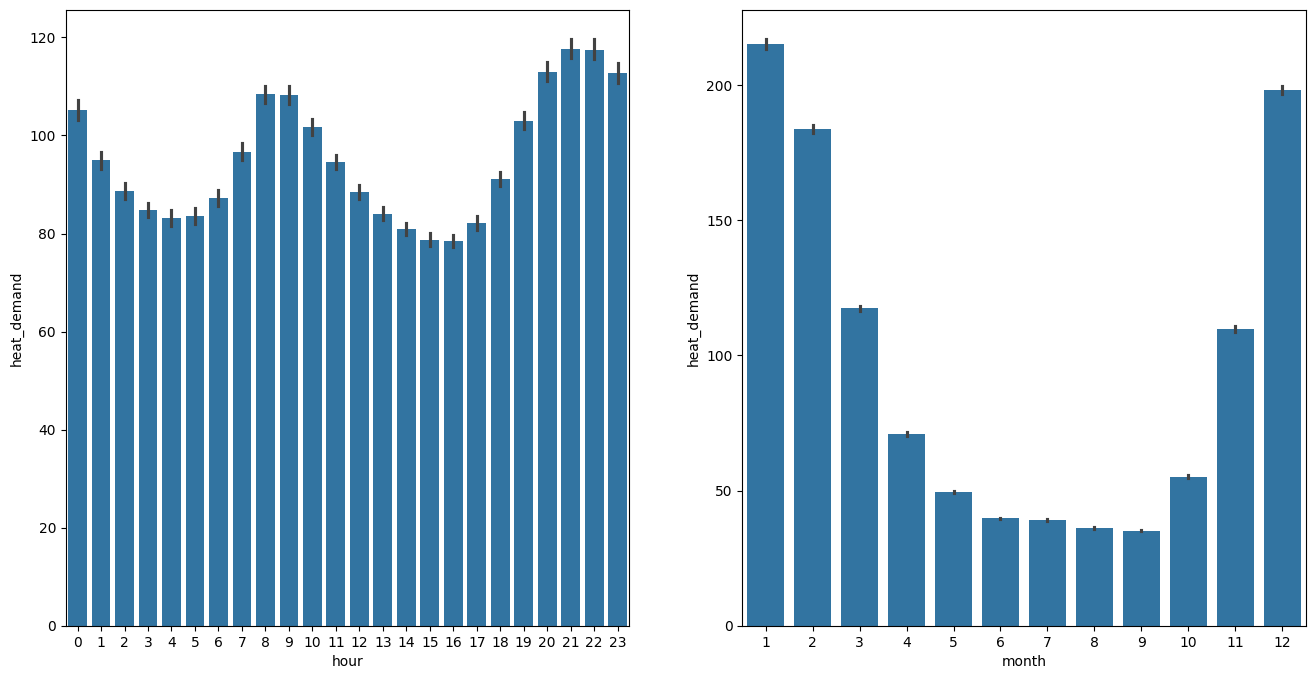

In [10]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.barplot(x='hour',y='heat_demand',data=df)
plt.subplot(1,2,2)
sns.barplot(x='month',y='heat_demand',data=df)
plt.show()

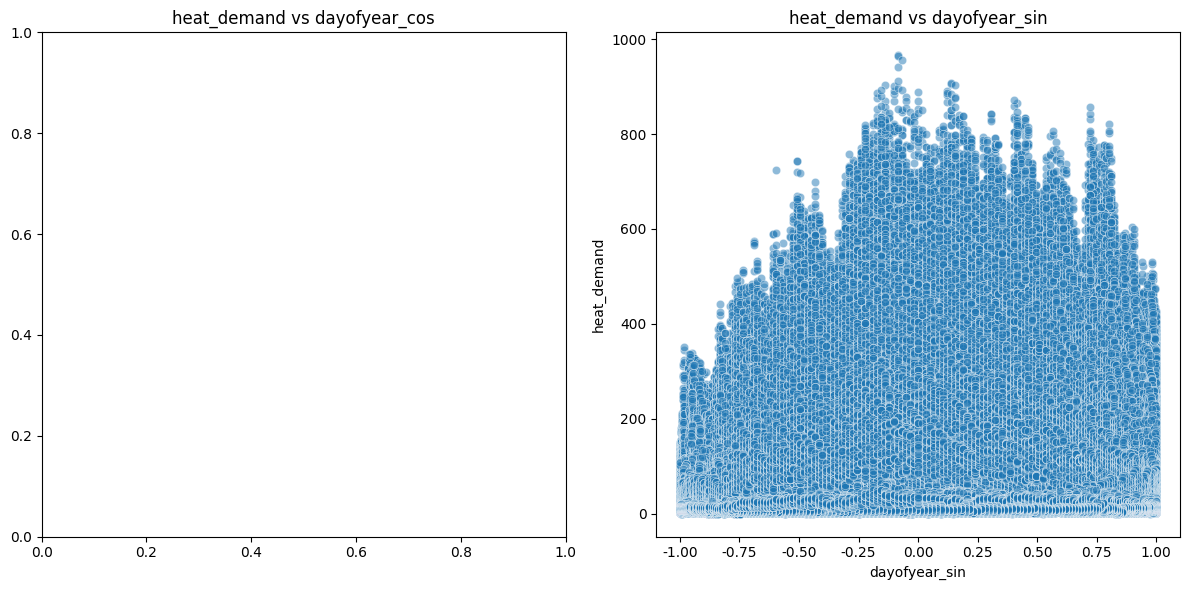

In [11]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
#sns.scatterplot(x='dayofyear_cos', y='heat_demand', data=df, alpha=0.5)
plt.title('heat_demand vs dayofyear_cos')

plt.subplot(1, 2, 2)
sns.scatterplot(x='dayofyear_sin', y='heat_demand', data=df, alpha=0.5)
plt.title('heat_demand vs dayofyear_sin')

plt.tight_layout()
plt.show()

In [12]:
# df['quadrant'] = np.select(
#         [
#             (df['wd'] >= 337.5) | (df['wd'] < 22.5),   # 북 (N)
#             (df['wd'] >= 22.5) & (df['wd'] < 67.5),    # 북동 (NE)
#             (df['wd'] >= 67.5) & (df['wd'] < 112.5),   # 동 (E)
#             (df['wd'] >= 112.5) & (df['wd'] < 157.5),  # 남동 (SE)
#             (df['wd'] >= 157.5) & (df['wd'] < 202.5),  # 남 (S)
#             (df['wd'] >= 202.5) & (df['wd'] < 247.5),  # 남서 (SW)
#             (df['wd'] >= 247.5) & (df['wd'] < 292.5),  # 서 (W)
#             (df['wd'] >= 292.5) & (df['wd'] < 337.5),  # 북서 (NW)
#         ],
#         ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
#         default='기타'  # 예외적처리
#     )

df['quadrant'] = np.select(
        [
            (df['wd'] >= 337.5) | (df['wd'] < 22.5),   # 북 (N)
            (df['wd'] >= 22.5) & (df['wd'] < 67.5),    # 북동 (NE)
            (df['wd'] >= 67.5) & (df['wd'] < 112.5),   # 동 (E)
            (df['wd'] >= 112.5) & (df['wd'] < 157.5),  # 남동 (SE)
            (df['wd'] >= 157.5) & (df['wd'] < 202.5),  # 남 (S)
            (df['wd'] >= 202.5) & (df['wd'] < 247.5),  # 남서 (SW)
            (df['wd'] >= 247.5) & (df['wd'] < 292.5),  # 서 (W)
            (df['wd'] >= 292.5) & (df['wd'] < 337.5),  # 북서 (NW)
        ],
        [1,2,3,4,5,6,7,8],
        default=-99  # 예외적처리
    )

df_test['quadrant'] = np.select(
    [
        (df_test['wd'] >= 337.5) | (df_test['wd'] < 22.5),   # 북 (N)
        (df_test['wd'] >= 22.5) & (df_test['wd'] < 67.5),    # 북동 (NE)
        (df_test['wd'] >= 67.5) & (df_test['wd'] < 112.5),   # 동 (E)
        (df_test['wd'] >= 112.5) & (df_test['wd'] < 157.5),  # 남동 (SE)
        (df_test['wd'] >= 157.5) & (df_test['wd'] < 202.5),  # 남 (S)
        (df_test['wd'] >= 202.5) & (df_test['wd'] < 247.5),  # 남서 (SW)
        (df_test['wd'] >= 247.5) & (df_test['wd'] < 292.5),  # 서 (W)
        (df_test['wd'] >= 292.5) & (df_test['wd'] < 337.5),  # 북서 (NW)
    ],
    [1, 2, 3, 4, 5, 6, 7, 8],
    default=-99  # 예외적 처리
)

In [13]:
# plt.figure(figsize=(16, 8))
# order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']  # 시계방향 순서
# sns.barplot(x='quadrant', y='heat_demand', data=df, order=order)
# plt.title("풍향 기준 정렬")
# plt.xlabel("풍향 (8방위)")
# plt.ylabel("평균 열수요량")
# plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

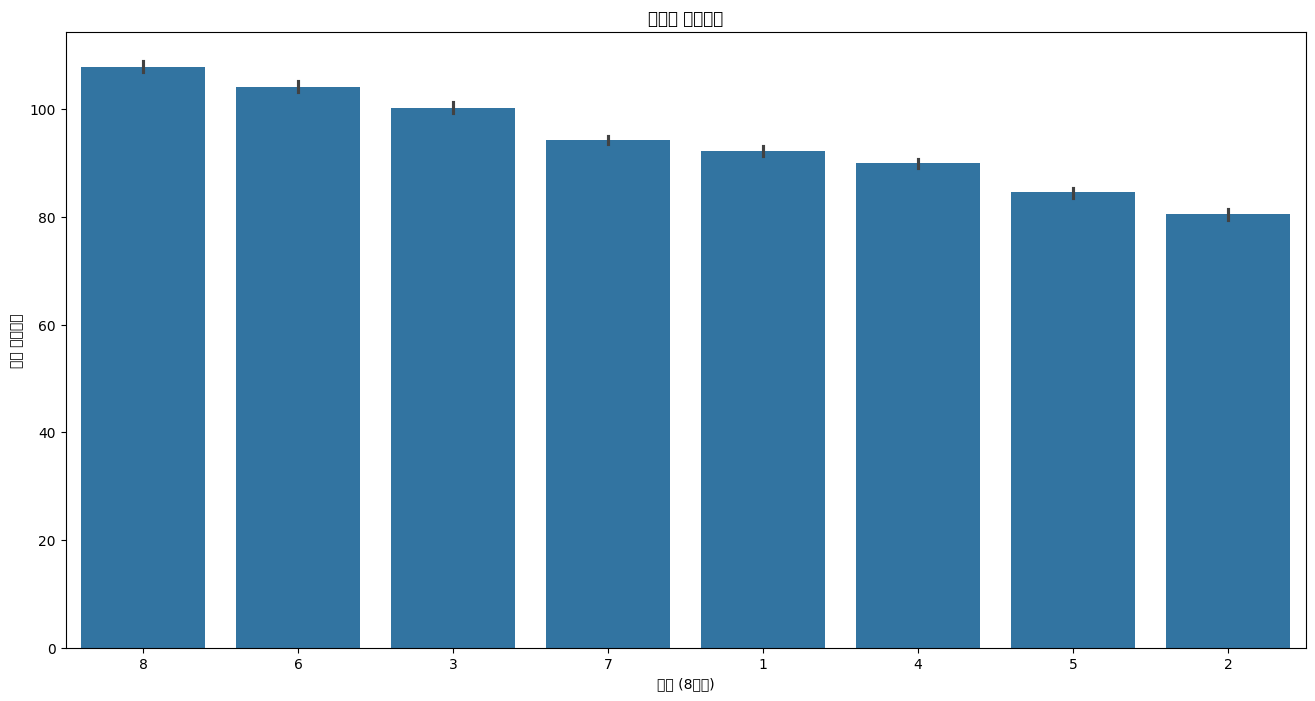

In [14]:
order_by_mean = (
    df.groupby('quadrant')['heat_demand']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

order_by_mean_test = (
    df_test.groupby('quadrant')['heat_demand']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)


plt.figure(figsize=(16, 8))
sns.barplot(x='quadrant', y='heat_demand', data=df, order=order_by_mean)
plt.title("풍향별 열수요량")
plt.xlabel("풍향 (8방위)")
plt.ylabel("평균 열수요량")
plt.show()

In [15]:
df['rain_day'] = np.where(df['rn_day']>0,1,0)
df.drop('rn_day', axis=1, inplace=True)

df_test['rain_day'] = np.where(df_test['rn_day'] > 0, 1, 0)
df_test.drop('rn_day', axis=1, inplace=True)

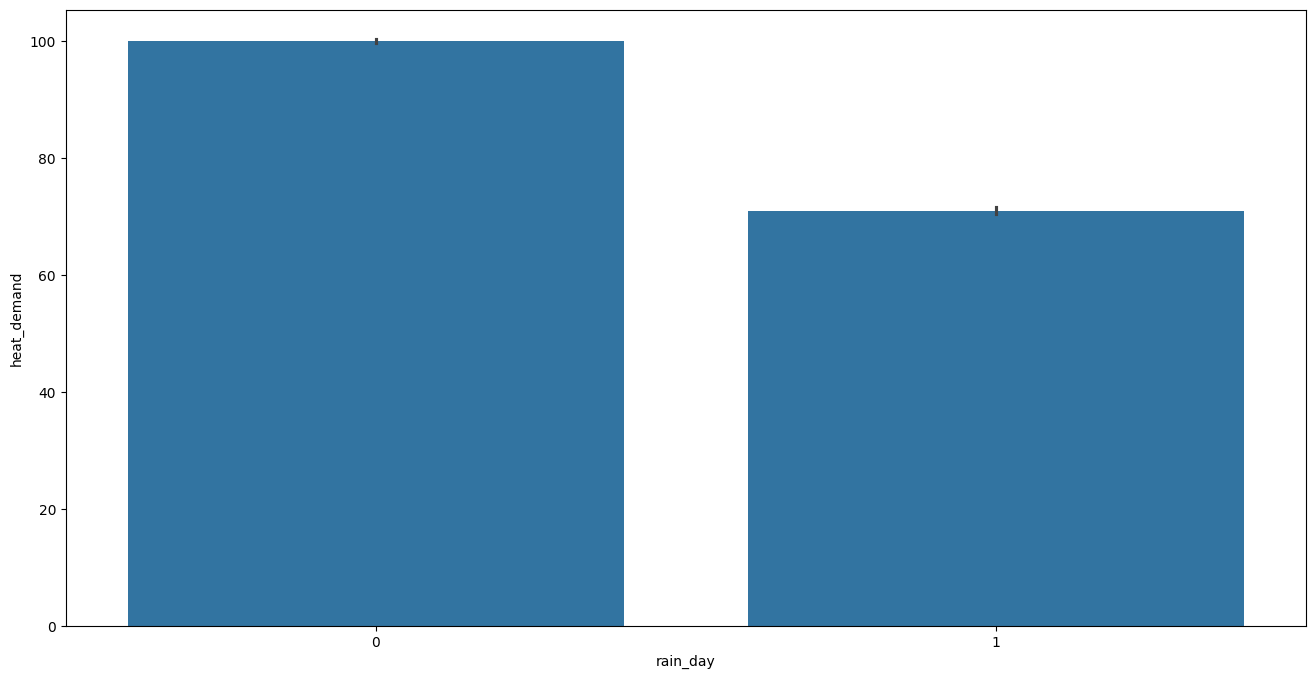

In [16]:
plt.figure(figsize=(16,8))
sns.barplot(x='rain_day',y='heat_demand',data=df)
plt.show()

In [17]:
df['heat_index_like'] = df['ta']*df['hm']
df['ta_moving_avg_24hr'] = df['ta'].rolling(window=24, min_periods=1).mean()
df['ta_moving_std_24hr'] = df['ta'].rolling(window=24, min_periods=1).std().round(2)
df['hm_moving_avg_24hr'] = df['hm'].rolling(window=24, min_periods=1).mean().round(2)
df['hm_moving_std_24hr'] = df['hm'].rolling(window=24, min_periods=1).std().round(2)
df['hm_moving_avg_12hr'] = df['hm'].rolling(window=12, min_periods=1).mean().round(2)

period = 24
period_month = 12

# 푸리에 변환(사인/코사인 변환) 특성 생성
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / period)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / period)
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / period_month) # -1을 하는 이유: 1월을 0으로 시작하는 것으로 간주
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / period_month) # -1을 하는 이유: 1월을 0으로 시작하는 것으로 간주


# You can add more lags, e.g., 2 hours, 24 hours
df['hm_lag_24hr'] = df['hm'].shift(24)

### Expanding Window Statistics
# Mean temperature from the beginning of the data up to the current point
df['ta_expanding_mean'] = df['ta'].expanding(min_periods=1).mean()
df['hm_expanding_std'] = df['hm'].expanding(min_periods=1).std().round(2)


def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

df['season'] = df['month'].apply(get_season)

In [18]:
df_test.columns

Index(['branch_id', 'ta', 'wd', 'ws', 'hm', 'heat_demand', 'month', 'hour',
       'is_weekend', 'dayofyear_sin', 'dayofyear_cos', 'date_index',
       'quadrant', 'rain_day'],
      dtype='object')

In [19]:
import numpy as np
import pandas as pd


# df_test가 이미 로드되어 있고, 필요한 컬럼('ta', 'hm', 'month', 'hour')이 존재한다고 가정합니다.
# 현재 df_test의 컬럼 이름은 이미 소문자이므로, 추가적인 .str.lower()는 필요 없습니다.

# 열지수 유사 변수 생성
df_test['heat_index_like'] = df_test['ta'] * df_test['hm']

# 이동 평균 및 표준편차 (24시간)
df_test['ta_moving_avg_24hr'] = df_test['ta'].rolling(window=24, min_periods=1).mean()
df_test['ta_moving_std_24hr'] = df_test['ta'].rolling(window=24, min_periods=1).std().round(2)
df_test['hm_moving_avg_24hr'] = df_test['hm'].rolling(window=24, min_periods=1).mean().round(2)
df_test['hm_moving_std_24hr'] = df_test['hm'].rolling(window=24, min_periods=1).std().round(2)

# 이동 평균 (12시간)
df_test['hm_moving_avg_12hr'] = df_test['hm'].rolling(window=12, min_periods=1).mean().round(2)


period = 24
period_month = 12

# 푸리에 변환 (사인/코사인 변환) 특성 생성
df_test['hour_sin'] = np.sin(2 * np.pi * df_test['hour'] / period)
df_test['hour_cos'] = np.cos(2 * np.pi * df_test['hour'] / period)
df_test['month_sin'] = np.sin(2 * np.pi * (df_test['month'] - 1) / period_month)
df_test['month_cos'] = np.cos(2 * np.pi * (df_test['month'] - 1) / period_month)

# 24시간 이전 습도 값 (Lag Feature)
df_test['hm_lag_24hr'] = df_test['hm'].shift(24)

# 확장 윈도우 통계
# 데이터 시작부터 현재 시점까지의 평균 온도
df_test['ta_expanding_mean'] = df_test['ta'].expanding(min_periods=1).mean()
# 데이터 시작부터 현재 시점까지의 습도 표준편차
df_test['hm_expanding_std'] = df_test['hm'].expanding(min_periods=1).std().round(2)


# 계절 변수 생성 함수
def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

df_test['season'] = df_test['month'].apply(get_season)

print("df_test에 추가 파생 변수 생성 완료.")
print(f"새로 추가된 df_test 컬럼: {['heat_index_like', 'ta_moving_avg_24hr', 'ta_moving_std_24hr', 'hm_moving_avg_24hr', 'hm_moving_std_24hr', 'hm_moving_avg_12hr', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'hm_lag_24hr', 'ta_expanding_mean', 'hm_expanding_std', 'season']}")
print(df_test[['heat_index_like', 'ta_moving_avg_24hr', 'season']].head())

df_test에 추가 파생 변수 생성 완료.
새로 추가된 df_test 컬럼: ['heat_index_like', 'ta_moving_avg_24hr', 'ta_moving_std_24hr', 'hm_moving_avg_24hr', 'hm_moving_std_24hr', 'hm_moving_avg_12hr', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'hm_lag_24hr', 'ta_expanding_mean', 'hm_expanding_std', 'season']
   heat_index_like  ta_moving_avg_24hr  season
0            48.55            0.500000  winter
1            38.72            0.450000  winter
2            -9.70            0.266667  winter
3           -77.52            0.000000  winter
4             9.70            0.020000  winter


In [20]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant
# import pandas as pd



# X = df[['ta_moving_avg_24hr', 'ta_moving_std_24hr', 'hm_moving_avg_24hr','hm_moving_std_24hr','hm_moving_avg_12hr','hm_lag_1hr','ta_lag_24hr','hm_lag_24hr','ta_expanding_mean','hm_expanding_std','ta_diff_1hr','hm_diff_1hr','ta_pct_change_1hr']]  # 독립변수들
# X = X.replace([np.inf, -np.inf], np.nan).dropna()
# X = add_constant(X)

# vif = pd.DataFrame()
# vif['feature'] = X.columns
# vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# print(vif)


In [21]:
df.sort_index(axis=1, inplace=True)
df_test.sort_index(axis=1, inplace=True)

In [22]:
df

,branch_id,date_index,dayofyear_cos,dayofyear_sin,heat_demand,heat_index_like,hm,hm_expanding_std,hm_lag_24hr,hm_moving_avg_12hr,...,month_sin,quadrant,rain_day,season,ta,ta_expanding_mean,ta_moving_avg_24hr,ta_moving_std_24hr,wd,ws
0,A,0,0.999852,1.721336e-02,281.0,-688.82,68.2,NaN,NaN,68.20,...,0.0,3,0,winter,-10.1,-10.100000,-10.100000,NaN,78.3,0.5
1,A,0,0.999852,1.721336e-02,262.0,-712.98,69.9,1.20,NaN,69.05,...,0.0,3,0,winter,-10.2,-10.150000,-10.150000,0.07,71.9,0.6
2,A,0,0.999852,1.721336e-02,266.0,-692.00,69.2,0.85,NaN,69.10,...,0.0,1,0,winter,-10.0,-10.100000,-10.100000,0.10,360.0,0.0
3,A,0,0.999852,1.721336e-02,285.0,-604.50,65.0,2.17,NaN,68.08,...,0.0,4,0,winter,-9.3,-9.900000,-9.900000,0.41,155.9,0.5
4,A,0,0.999852,1.721336e-02,283.0,-571.50,63.5,2.78,NaN,67.16,...,0.0,3,0,winter,-9.0,-9.720000,-9.720000,0.54,74.3,1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499296,S,1094,1.000000,6.432491e-16,34.0,292.80,91.5,21.19,90.0,89.87,...,-0.5,6,1,winter,3.2,13.738646,3.637500,0.64,233.5,0.4
499297,S,1094,1.000000,6.432491e-16,35.0,267.09,92.1,21.19,88.9,89.37,...,-0.5,6,1,winter,2.9,13.738622,3.620833,0.66,227.4,0.1
499298,S,1094,1.000000,6.432491e-16,35.0,195.93,93.3,21.19,87.0,89.18,...,-0.5,1,1,winter,2.1,13.738596,3.562500,0.73,360.0,0.0
499299,S,1094,1.000000,6.432491e-16,40.0,210.10,95.5,21.19,94.9,89.41,...,-0.5,2,1,winter,2.2,13.738570,3.529167,0.77,30.0,1.4


In [23]:
df_test

,branch_id,date_index,dayofyear_cos,dayofyear_sin,heat_demand,heat_index_like,hm,hm_expanding_std,hm_lag_24hr,hm_moving_avg_12hr,...,month_sin,quadrant,rain_day,season,ta,ta_expanding_mean,ta_moving_avg_24hr,ta_moving_std_24hr,wd,ws
0,A,0,0.999852,0.017213,NaN,48.55,97.1,NaN,NaN,97.10,...,0.0,5,1,winter,0.5,0.500000,0.500000,NaN,171.3,0.8
1,A,0,0.999852,0.017213,NaN,38.72,96.8,0.21,NaN,96.95,...,0.0,3,0,winter,0.4,0.450000,0.450000,0.07,93.7,1.0
2,A,0,0.999852,0.017213,NaN,-9.70,97.0,0.15,NaN,96.97,...,0.0,4,0,winter,-0.1,0.266667,0.266667,0.32,133.0,0.8
3,A,0,0.999852,0.017213,NaN,-77.52,96.9,0.13,NaN,96.95,...,0.0,6,0,winter,-0.8,0.000000,0.000000,0.59,218.6,0.6
4,A,0,0.999852,0.017213,NaN,9.70,97.0,0.11,NaN,96.96,...,0.0,2,0,winter,0.1,0.020000,0.020000,0.52,58.7,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166910,S,365,0.999852,0.017213,NaN,-50.38,45.8,19.84,71.2,37.84,...,-0.5,1,0,winter,-1.1,14.710660,1.429167,2.09,360.0,0.0
166911,S,365,0.999852,0.017213,NaN,-62.79,48.3,19.84,75.0,38.41,...,-0.5,1,0,winter,-1.3,14.710562,1.175000,2.03,360.0,0.0
166912,S,365,0.999852,0.017213,NaN,-144.00,60.0,19.84,75.2,40.65,...,-0.5,1,0,winter,-2.4,14.710458,0.879167,2.01,360.0,0.0
166913,S,365,0.999852,0.017213,NaN,-236.52,65.7,19.84,79.2,43.53,...,-0.5,1,0,winter,-3.6,14.710347,0.554167,2.08,360.0,0.0


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd



X = df[['ta_expanding_mean', 'hm_expanding_std','dayofyear_cos','date_index','hour','ta','hm']]  # 독립변수들
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = add_constant(X)

vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


             feature          VIF
0              const  4923.877466
1  ta_expanding_mean     1.196970
2   hm_expanding_std     1.172119
3      dayofyear_cos     3.844572
4         date_index     1.048611
5               hour     1.153689
6                 ta     3.791926
7                 hm     1.171448


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4006
[LightGBM] [Info] Number of data points in the train set: 358276, number of used features: 46
[LightGBM] [Info] Start training from score 95.126852
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

R2   : 0.9934593744398799


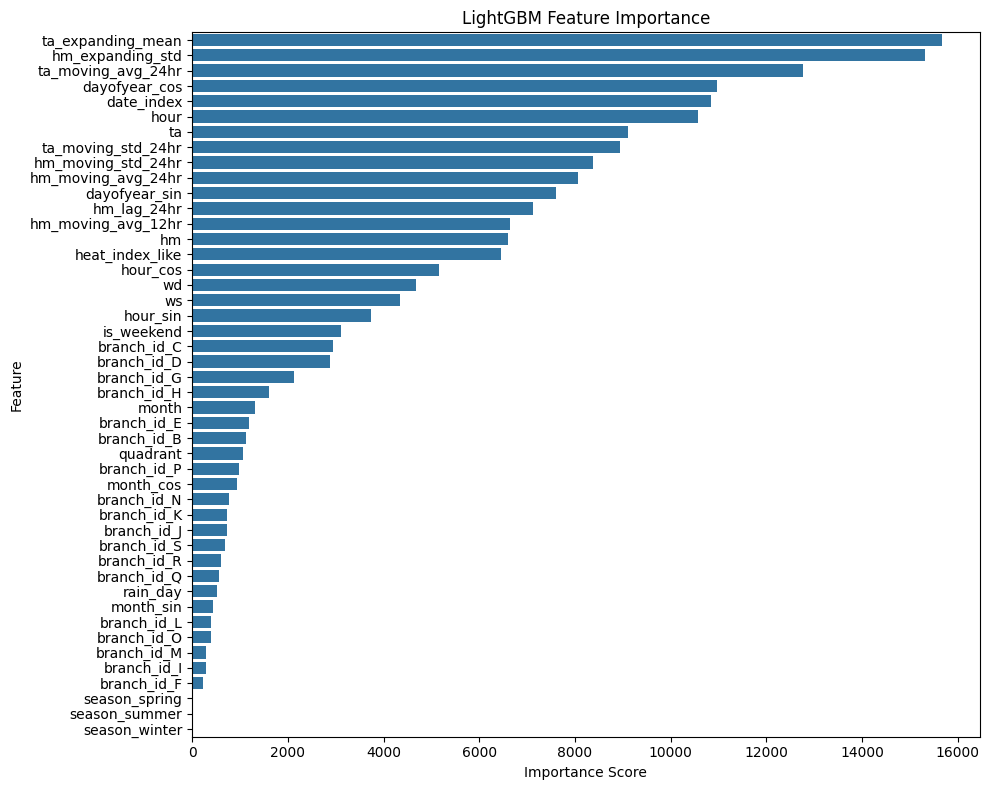

In [ ]:
# 원-핫 인코딩
df = pd.get_dummies(df, columns=['branch_id','season'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['branch_id','season'], drop_first=True)

# x, y 분리
x = df.drop('heat_demand', axis=1)
y = df['heat_demand']

# x, y 분리
x_final_valid = df_test.drop('heat_demand', axis=1)
y_final_valid = df_test['heat_demand']

# 분할
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)


# LightGBM 모델 정의
LEARNING_RATE=0.05
model = lightgbm.LGBMRegressor(
        objective='regression',
        learning_rate=LEARNING_RATE,
        n_estimators=3000,
        num_leaves=64,
        max_depth=8
    )

# 학습
model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='rmse',
    callbacks=[lightgbm.early_stopping(stopping_rounds=10)]
)
rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, model.predict(x_test)))
# 평가 출력
print("LightGBM 결과")
print("RMSE :", rmse)
print("MAE  :", sk.metrics.mean_absolute_error(y_test, model.predict(x_test)))
print("R2   :", sk.metrics.r2_score(y_test, model.predict(x_test)))

# 중요도 추출 (split은 등장 횟수 기준, gain은 손실 감소량 기준)
importances = model.feature_importances_  # 기본은 split 기준
feature_names = x.columns

# 정리해서 시각화
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=importance_df, y=importance_df.index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
df.sort_index(axis=1, inplace=True)
df_test.sort_index(axis=1, inplace=True)

In [ ]:
df.columns

Index(['branch_id_B', 'branch_id_C', 'branch_id_D', 'branch_id_E',
       'branch_id_F', 'branch_id_G', 'branch_id_H', 'branch_id_I',
       'branch_id_J', 'branch_id_K', 'branch_id_L', 'branch_id_M',
       'branch_id_N', 'branch_id_O', 'branch_id_P', 'branch_id_Q',
       'branch_id_R', 'branch_id_S', 'date_index', 'dayofyear_cos',
       'dayofyear_sin', 'heat_demand', 'heat_index_like', 'hm',
       'hm_expanding_std', 'hm_lag_24hr', 'hm_moving_avg_12hr',
       'hm_moving_avg_24hr', 'hm_moving_std_24hr', 'hour', 'hour_cos',
       'hour_sin', 'is_weekend', 'month', 'month_cos', 'month_sin', 'quadrant',
       'rain_day', 'season_spring', 'season_summer', 'season_winter', 'ta',
       'ta_expanding_mean', 'ta_moving_avg_24hr', 'ta_moving_std_24hr', 'wd',
       'ws'],
      dtype='object')

In [ ]:
y_pred = model.predict(x_final_valid)
print("y_pred:", y_pred)


y_pred: [229.71091363 230.64935441 224.57014066 ... 619.29674    638.83697745
 538.60501336]


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

import pandas as pd

# 행을 쉽게 삭제하기 위해 데이터를 결합합니다.
train_data = pd.concat([x_train, y_train], axis=1)
train_data.replace([np.inf, -np.inf], np.nan, inplace=True) # 먼저 inf를 NaN으로 대체합니다.
train_data.dropna(inplace=True)

# 다시 분할합니다.
x_train = train_data.iloc[:, :-y_train.shape[1]] if isinstance(y_train, pd.DataFrame) else train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -y_train.shape[1]:] if isinstance(y_train, pd.DataFrame) else train_data.iloc[:, -1]

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    n_estimators=3000,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    )
xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)
print('model_score:', xgb_model.score(x_test, y_test))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('MAPE:', mean_absolute_percentage_error(y_test, y_pred))
print('R2-Score:', r2_score(y_test, y_pred))

model_score: 0.994773648279154
MAE: 5.208073230399296
MSE: 69.6235162284865
RMSE: 8.344070722883794
MAPE: 4658577803136.015
R2-Score: 0.994773648279154


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb # XGBoost 라이브러리 임포트

df_temp = pd.read_csv(PATH +"test_heat.csv")
df_test = df_temp.copy()

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


new_column_names_map = {
    'TM': 'tm',
    'branch_ID': 'branch_id', # ID는 소문자 id로 변경
    'TA': 'ta',
    'WD': 'wd',
    'WS': 'ws',
    'RN_DAY': 'rn_day',
    'RN_HR1': 'rn_hr1',
    'HM': 'hm',
    'SI': 'si',
    'ta_chi': 'ta_chi',
    'heat_demand': 'heat_demand'
}

df_test.rename(columns=new_column_names_map, inplace=True)

try:
    _ = xgb_model
    print("XGBoost 모델 객체 (xgb_model)가 사용될 준비가 되었습니다.")
except NameError:
    print("오류: 'xgb_model' 변수가 정의되지 않았습니다. XGBoost 모델 객체를 먼저 할당해주세요.")
    print("스크립트를 종료합니다.")
    exit()

# TODO: 이제 final_train_features_columns를 모델의 내부 피처 이름으로 설정합니다.
# XGBoost 1.6 이상 버전에서는 .feature_names_in_를 사용합니다.
# 이전 버전에서는 .feature_names를 사용해야 할 수도 있습니다.
try:
    final_train_features_columns = list(xgb_model.feature_names_in_)
except AttributeError:
    # .feature_names_in_가 없는 경우 .feature_names 시도 (이전 버전 호환)
    try:
        final_train_features_columns = list(xgb_model.feature_names)
    except AttributeError:
        print("오류: 'xgb_model'에서 feature_names_in_ 또는 feature_names를 찾을 수 없습니다.")
        print("이는 모델이 제대로 학습되지 않았거나, 예상치 못한 형식일 수 있습니다.")
        print("스크립트를 종료합니다.")
        exit()

print("final_train_features_columns가 학습된 모델의 피처 이름으로 설정되었습니다.")
# 현재 final_train_features_columns의 순서를 확인해볼 수 있습니다.
# print(f"모델 피처 순서 (final_train_features_columns):\n{final_train_features_columns}")


print("\n--- df_test 전처리 (모든 행 유지) ---")

df_test_working = df_test.copy()
df_test_working.columns = df_test_working.columns.str.lower()

if 'tm' not in df_test_working.columns:
    print("경고: 테스트 데이터에 'tm' 컬럼이 없습니다. 날짜/시간 기반 피처가 제대로 생성되지 않을 수 있습니다.")
    has_tm_column = False
else:
    has_tm_column = True

for col in df_test_working.columns:
    if col != 'tm':
        df_test_working[col] = np.where(df_test_working[col] == -99, np.nan, df_test_working[col])
if 'wd' in df_test_working.columns:
    df_test_working['wd'] = np.where(df_test_working['wd'] < 0, np.nan, df_test_working['wd'])

cols_to_drop_initial_test = ['si', 'rn_hr1', 'ta_chi']
existing_cols_to_drop_test = [col for col in cols_to_drop_initial_test if col in df_test_working.columns]
if existing_cols_to_drop_test:
    df_test_working.drop(existing_cols_to_drop_test, axis=1, inplace=True)

if has_tm_column:
    df_test_working['tm'] = pd.to_datetime(df_test_working['tm'].astype(str), format='%Y%m%d%H', errors='coerce')
    df_test_working['month'] = df_test_working['tm'].dt.month
    df_test_working['hour'] = df_test_working['tm'].dt.hour
    df_test_working['weekday'] = df_test_working['tm'].dt.dayofweek
    df_test_working['is_weekend'] = df_test_working['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    df_test_working['dayofyear'] = df_test_working['tm'].dt.dayofyear
    df_test_working['dayofyear_sin'] = np.sin(2 * np.pi * df_test_working['dayofyear'] / 365)
    df_test_working['dayofyear_cos'] = np.cos(2 * np.pi * df_test_working['dayofyear'] / 365)
    df_test_working['date_index'] = (df_test_working['tm'] - df_test_working['tm'].min()).dt.days
else:
    df_test_working['month'] = 0
    df_test_working['hour'] = 0
    df_test_working['is_weekend'] = 0
    df_test_working['dayofyear_sin'] = 0
    df_test_working['dayofyear_cos'] = 0
    df_test_working['date_index'] = 0

if 'wd' in df_test_working.columns:
    df_test_working['quadrant'] = np.select(
        [
            (df_test_working['wd'] >= 337.5) | (df_test_working['wd'] < 22.5),
            (df_test_working['wd'] >= 22.5) & (df_test_working['wd'] < 67.5),
            (df_test_working['wd'] >= 67.5) & (df_test_working['wd'] < 112.5),
            (df_test_working['wd'] >= 112.5) & (df_test_working['wd'] < 157.5),
            (df_test_working['wd'] >= 157.5) & (df_test_working['wd'] < 202.5),
            (df_test_working['wd'] >= 202.5) & (df_test_working['wd'] < 247.5),
            (df_test_working['wd'] >= 247.5) & (df_test_working['wd'] < 292.5),
            (df_test_working['wd'] >= 292.5) & (df_test_working['wd'] < 337.5),
        ],
        [1, 2, 3, 4, 5, 6, 7, 8],
        default=-99
    )
else:
    print("Warning: 'wd' column not found in test data. Skipping 'quadrant' creation.")
    df_test_working['quadrant'] = -99

if 'rn_day' in df_test_working.columns:
    df_test_working['rain_day'] = np.where(df_test_working['rn_day'] > 0, 1, 0)
    df_test_working.drop('rn_day', axis=1, inplace=True)
else:
    if 'rain_day' in final_train_features_columns:
        df_test_working['rain_day'] = 0

if 'ta' in df_test_working.columns and 'hm' in df_test_working.columns:
    df_test_working['heat_index_like'] = df_test_working['ta'] * df_test_working['hm']
    df_test_working['ta_moving_avg_24hr'] = df_test_working['ta'].rolling(window=24, min_periods=1).mean()
    df_test_working['ta_moving_std_24hr'] = df_test_working['ta'].rolling(window=24, min_periods=1).std().round(2)
    df_test_working['hm_moving_avg_24hr'] = df_test_working['hm'].rolling(window=24, min_periods=1).mean().round(2)
    df_test_working['hm_moving_std_24hr'] = df_test_working['hm'].rolling(window=24, min_periods=1).std().round(2)
    df_test_working['hm_moving_avg_12hr'] = df_test_working['hm'].rolling(window=12, min_periods=1).mean().round(2)
    df_test_working['hm_lag_24hr'] = df_test_working['hm'].shift(24)
    df_test_working['ta_expanding_mean'] = df_test_working['ta'].expanding(min_periods=1).mean()
    df_test_working['hm_expanding_std'] = df_test_working['hm'].expanding(min_periods=1).std().round(2)
else:
    print("Warning: 'ta' or 'hm' column not found in test data. Skipping related feature creation.")
    for col in ['heat_index_like', 'ta_moving_avg_24hr', 'ta_moving_std_24hr',
                'hm_moving_avg_24hr', 'hm_moving_std_24hr', 'hm_moving_avg_12hr',
                'hm_lag_24hr', 'ta_expanding_mean', 'hm_expanding_std']:
        if col in final_train_features_columns:
            df_test_working[col] = 0

period = 24
period_month = 12
if 'hour' in df_test_working.columns:
    df_test_working['hour_sin'] = np.sin(2 * np.pi * df_test_working['hour'] / period)
    df_test_working['hour_cos'] = np.cos(2 * np.pi * df_test_working['hour'] / period)
else:
    if 'hour_sin' in final_train_features_columns: df_test_working['hour_sin'] = 0
    if 'hour_cos' in final_train_features_columns: df_test_working['hour_cos'] = 0

if 'month' in df_test_working.columns:
    df_test_working['month_sin'] = np.sin(2 * np.pi * (df_test_working['month'] - 1) / period_month)
    df_test_working['month_cos'] = np.cos(2 * np.pi * (df_test_working['month'] - 1) / period_month)
else:
    if 'month_sin' in final_train_features_columns: df_test_working['month_sin'] = 0
    if 'month_cos' in final_train_features_columns: df_test_working['month_cos'] = 0


def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

if 'month' in df_test_working.columns:
    df_test_working['season'] = df_test_working['month'].apply(get_season)
else:
    if 'season_unknown' in final_train_features_columns:
        df_test_working['season'] = 'unknown'
    else:
        pass

cols_to_drop_final_test = ['tm', 'weekday', 'dayofyear']
existing_cols_to_drop_final_test = [col for col in cols_to_drop_final_test if col in df_test_working.columns]
if existing_cols_to_drop_final_test:
    df_test_working.drop(existing_cols_to_drop_final_test, axis=1, inplace=True)

x_test_for_prediction = df_test_working.drop(columns=['heat_demand'], errors='ignore')

categorical_cols_to_encode = []
if 'branch_id' in x_test_for_prediction.columns:
    categorical_cols_to_encode.append('branch_id')
if 'season' in x_test_for_prediction.columns:
    categorical_cols_to_encode.append('season')

if categorical_cols_to_encode:
    # drop_first=True는 원-핫 인코딩 시 하나의 더미 변수를 제거하여 다중 공선성을 방지합니다.
    # 훈련 시에도 drop_first=True를 사용했는지 확인해야 합니다.
    x_test_for_prediction = pd.get_dummies(x_test_for_prediction, columns=categorical_cols_to_encode, drop_first=True)


# --- 15. 컬럼 매핑: x_test_for_prediction의 컬럼을 훈련 데이터 컬럼에 맞춤 (가장 중요!) ---
# 이 부분이 'feature_names mismatch' 오류를 해결하는 핵심입니다.

# 테스트 데이터에 없는 훈련 컬럼은 0으로 채웁니다.
missing_cols_in_test = set(final_train_features_columns) - set(x_test_for_prediction.columns)
for c in missing_cols_in_test:
    x_test_for_prediction[c] = 0

# 테스트 데이터에 있지만 훈련 컬럼에는 없는 컬럼은 삭제합니다.
extra_cols_in_test = set(x_test_for_prediction.columns) - set(final_train_features_columns)
if extra_cols_in_test:
    x_test_for_prediction.drop(columns=list(extra_cols_in_test), inplace=True)

# 최종적으로 컬럼 순서를 final_train_features_columns와 동일하게 맞춥니다.
# 이 줄이 가장 중요하며, 에러를 발생시킨 문제의 원인이었습니다.
x_test_for_prediction = x_test_for_prediction[final_train_features_columns]

print(f"테스트 데이터 최종 피처 컬럼 수: {len(x_test_for_prediction.columns)}")
print(f"테스트 데이터 결측치 개수 (전처리 후, 예측 전): \n{x_test_for_prediction.isnull().sum().sum()}")

print("\n--- 예측 수행 ---")
# 학습된 모델 (xgb_model)을 사용하여 예측을 수행합니다.
predicted_heat_demand_values = xgb_model.predict(x_test_for_prediction)

print("\n--- 예측값 매핑 및 제출 파일 준비 ---")

# 1. 'test_heat.csv' 파일을 불러와 원본 검증셋 DataFrame을 생성합니다.
# 이 파일에 예측된 heat_demand 값을 채워 넣을 것입니다.
try:
    df_final_submission = pd.read_csv('test_heat.csv')
except FileNotFoundError:
    print("오류: 'test_heat.csv' 파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.")
    # 파일이 없으면 더 이상 진행할 수 없으므로 종료하거나 적절히 처리합니다.
    exit()

df_test['heat_demand'] = np.nan
df_test.loc[x_test_for_prediction.index, 'heat_demand'] = predicted_heat_demand_values

# 3. heat_demand 값을 최종 검증 셋에 적용하기 전에 후처리합니다.
# 음수 값은 0으로 만들고, 소수점 첫째 자리까지 반올림합니다.
df_test['heat_demand'] = df_test['heat_demand'].apply(lambda x: max(0, x))
df_test['heat_demand'] = df_test['heat_demand'].round(1)

# 4. 이제 df_final_submission (원본 test_heat.csv)에
# df_test에서 처리된 heat_demand 값을 채워 넣습니다.
# 중요한 것은 인덱스를 기준으로 값을 일치시키는 것입니다.
# df_final_submission과 df_test의 행 순서 및 인덱스가 일치한다고 가정합니다.
# 만약 인덱스가 다르면 merge나 join 등을 고려해야 합니다.
df_final_submission['heat_demand'] = df_test['heat_demand']

# 5. 최종적으로 heat_demand가 채워진 DataFrame을 CSV 파일로 저장합니다.
# 보통 'submission.csv'나 'final_validation_set.csv'와 같이 제출 파일명으로 저장합니다.
df_final_submission.to_csv('submission.csv', index=False)

print("\n'heat_demand' 컬럼이 채워진 최종 검증셋(submission.csv)이 성공적으로 생성되었습니다.")
print(f"생성된 파일의 상위 5개 행:\n{df_final_submission.head()}")
print(f"df_final_submission의 최종 행 개수: {len(df_final_submission)}")
print(f"heat_demand 컬럼의 최종 결측치 개수: {df_final_submission['heat_demand'].isnull().sum()}")

XGBoost 모델 객체 (xgb_model)가 사용될 준비가 되었습니다.
final_train_features_columns가 학습된 모델의 피처 이름으로 설정되었습니다.

--- df_test 전처리 (모든 행 유지) ---
테스트 데이터 최종 피처 컬럼 수: 46
테스트 데이터 결측치 개수 (전처리 후, 예측 전): 
47011

--- 예측 수행 ---

--- 예측값 매핑 및 제출 파일 준비 ---
오류: 'test_heat.csv' 파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.


NameError: name 'df_final_submission' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- 0. 데이터 로드 (예시, 실제 데이터 경로에 맞게 수정 필요) ---
# df = pd.read_csv('train.csv') # 훈련 데이터 로드
# df_test = pd.read_csv('test.csv') # 테스트 데이터 로드

# 데이터 로드가 이미 진행되었다고 가정합니다.
# 만약 df와 df_test가 아직 로드되지 않았다면, 주석을 해제하고 경로를 지정해주세요.
# 예시 더미 데이터 (실제 데이터 대신 사용할 경우)
# 이 부분은 실제 데이터 로드 시 주석 처리하거나 삭제하세요.
try:
    df.head()
    df_test.head()
    print("df와 df_test가 이미 로드되어 있습니다. 더미 데이터 생성 단계는 건너뜝니다.")
except NameError:
    print("df 또는 df_test가 로드되지 않아 더미 데이터를 생성합니다.")
    from sklearn.datasets import make_regression
    X_dummy, y_dummy = make_regression(n_samples=1000, n_features=20, random_state=42)
    df = pd.DataFrame(X_dummy, columns=[f'feature_{i}' for i in range(20)])
    df['heat_demand'] = y_dummy + 100
    df['branch_id'] = np.random.choice(['A', 'B', 'C'], 1000)
    df['tm'] = pd.to_datetime(pd.date_range(start='2020-01-01', periods=1000, freq='H').astype(int))
    df['wd'] = np.random.rand(1000) * 360
    df['si'] = np.random.rand(1000)
    df['rn_hr1'] = np.random.rand(1000)
    df['ta_chi'] = np.random.rand(1000)
    df['hm'] = np.random.rand(1000) * 100
    df['ta'] = np.random.rand(1000) * 30
    df.loc[50:55, ['wd', 'hm']] = -99 # 훈련 데이터 예시 이상치
    df.loc[60:62, ['ta', 'si']] = np.nan # 훈련 데이터 예시 결측치

    df_test = pd.DataFrame(X_dummy[800:], columns=[f'feature_{i}' for i in range(20)])
    df_test['heat_demand'] = np.nan
    df_test['branch_id'] = np.random.choice(['A', 'B', 'C'], 200)
    df_test['tm'] = pd.to_datetime(pd.date_range(start='2020-02-10', periods=200, freq='H').astype(int))
    df_test['wd'] = np.random.rand(200) * 360
    df_test['si'] = np.random.rand(200)
    df_test['rn_hr1'] = np.random.rand(200)
    df_test['ta_chi'] = np.random.rand(200)
    df_test['hm'] = np.random.rand(200) * 100
    df_test['ta'] = np.random.rand(200) * 30
    df_test.loc[100:105, 'ta'] = -99 # 테스트 데이터 예시 이상치
    df_test.loc[110:112, 'hm'] = np.nan # 테스트 데이터 예시 결측치


print("--- 훈련 데이터 (df) 전처리 및 최종 피처 컬럼 저장 ---")
# 훈련 데이터 복사본 생성 (원본 df는 건드리지 않음)
df_train_processed = df.copy()

# 훈련 데이터 컬럼명 소문자 통일 (df_test와 일관성 유지)
df_train_processed.columns = df_train_processed.columns.str.lower()

# 이상치 처리 (-99를 NaN으로, wd의 음수 값 처리) - 훈련 데이터에도 동일하게 적용
for col in df_train_processed.columns:
    if col != 'tm': # 'tm' 컬럼은 이상치 처리가 필요 없음
        df_train_processed[col] = np.where(df_train_processed[col] == -99, np.nan, df_train_processed[col])
df_train_processed['wd'] = np.where(df_train_processed['wd'] < 0, np.nan, df_train_processed['wd'])

# 불필요한 컬럼 제거 - 훈련 데이터에도 동일하게 적용
cols_to_drop_initial_train = ['si', 'rn_hr1', 'ta_chi']
existing_cols_to_drop_train = [col for col in cols_to_drop_initial_train if col in df_train_processed.columns]
if existing_cols_to_drop_train:
    df_train_processed.drop(existing_cols_to_drop_train, axis=1, inplace=True)

# 날짜 파싱 및 파생 변수 생성 (month, hour)
df_train_processed['tm'] = pd.to_datetime(df_train_processed['tm'].astype(int), format='%Y%m%d%H')
df_train_processed['month'] = df_train_processed['tm'].dt.month
df_train_processed['hour'] = df_train_processed['tm'].dt.hour

# 요일 및 주말 여부
df_train_processed['weekday'] = df_train_processed['tm'].dt.dayofweek
df_train_processed['is_weekend'] = df_train_processed['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 계절성 변수 (dayofyear_sin, dayofyear_cos)
df_train_processed['dayofyear'] = df_train_processed['tm'].dt.dayofyear
df_train_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_train_processed['dayofyear'] / 365)
df_train_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_train_processed['dayofyear'] / 365)

# 날짜 인덱스 (relative_time)
df_train_processed['date_index'] = (df_train_processed['tm'] - df_train_processed['tm'].min()).dt.days

# quadrant 컬럼 생성
df_train_processed['quadrant'] = np.select(
    [
        (df_train_processed['wd'] >= 337.5) | (df_train_processed['wd'] < 22.5),
        (df_train_processed['wd'] >= 22.5) & (df_train_processed['wd'] < 67.5),
        (df_train_processed['wd'] >= 67.5) & (df_train_processed['wd'] < 112.5),
        (df_train_processed['wd'] >= 112.5) & (df_train_processed['wd'] < 157.5),
        (df_train_processed['wd'] >= 157.5) & (df_train_processed['wd'] < 202.5),
        (df_train_processed['wd'] >= 202.5) & (df_train_processed['wd'] < 247.5),
        (df_train_processed['wd'] >= 247.5) & (df_train_processed['wd'] < 292.5),
        (df_train_processed['wd'] >= 292.5) & (df_train_processed['wd'] < 337.5),
    ],
    [1, 2, 3, 4, 5, 6, 7, 8],
    default=-99
)

# rain_day 컬럼 생성 및 rn_day 제거
if 'rn_day' in df_train_processed.columns:
    df_train_processed['rain_day'] = np.where(df_train_processed['rn_day'] > 0, 1, 0)
    df_train_processed.drop('rn_day', axis=1, inplace=True)

# 추가 파생 변수 생성
df_train_processed['heat_index_like'] = df_train_processed['ta'] * df_train_processed['hm']
df_train_processed['ta_moving_avg_24hr'] = df_train_processed['ta'].rolling(window=24, min_periods=1).mean()
df_train_processed['ta_moving_std_24hr'] = df_train_processed['ta'].rolling(window=24, min_periods=1).std().round(2)
df_train_processed['hm_moving_avg_24hr'] = df_train_processed['hm'].rolling(window=24, min_periods=1).mean().round(2)
df_train_processed['hm_moving_std_24hr'] = df_train_processed['hm'].rolling(window=24, min_periods=1).std().round(2)
df_train_processed['hm_moving_avg_12hr'] = df_train_processed['hm'].rolling(window=12, min_periods=1).mean().round(2)

period = 24
period_month = 12
df_train_processed['hour_sin'] = np.sin(2 * np.pi * df_train_processed['hour'] / period)
df_train_processed['hour_cos'] = np.cos(2 * np.pi * df_train_processed['hour'] / period)
df_train_processed['month_sin'] = np.sin(2 * np.pi * (df_train_processed['month'] - 1) / period_month)
df_train_processed['month_cos'] = np.cos(2 * np.pi * (df_train_processed['month'] - 1) / period_month)
df_train_processed['hm_lag_24hr'] = df_train_processed['hm'].shift(24)
df_train_processed['ta_expanding_mean'] = df_train_processed['ta'].expanding(min_periods=1).mean()
df_train_processed['hm_expanding_std'] = df_train_processed['hm'].expanding(min_periods=1).std().round(2)

def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'
df_train_processed['season'] = df_train_processed['month'].apply(get_season)

# 최종 불필요한 컬럼 제거
df_train_processed.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

# 훈련 데이터 결측치 처리: LightGBM은 NaN을 직접 처리할 수 있으므로, 명시적인 dropna/fillna를 하지 않습니다.
# 만약 다른 모델을 사용한다면, 여기서 .fillna() 등으로 결측치를 채워야 합니다.
# 예: df_train_processed.fillna(df_train_processed.mean(), inplace=True)

# 원-핫 인코딩
df_train_processed = pd.get_dummies(df_train_processed, columns=['branch_id','season'], drop_first=True)

# 훈련 데이터의 x, y 분리
x = df_train_processed.drop('heat_demand', axis=1)
y = df_train_processed['heat_demand']

# 모델 학습에 사용될 최종 피처 컬럼 이름 리스트를 저장합니다. (매우 중요!)
# 이 리스트가 df_test 컬럼을 맞추는 기준이 됩니다.
final_train_features_columns = x.columns.tolist()
print(f"훈련 데이터 최종 피처 컬럼 수: {len(final_train_features_columns)}")
# print(f"훈련 데이터 최종 피처 컬럼:\n{final_train_features_columns}")


print("\n--- 모델 학습 (LightGBM) ---")
# 모델 정의
LEARNING_RATE = 0.05
model = lgb.LGBMRegressor(
    objective='regression',
    learning_rate=LEARNING_RATE,
    n_estimators=3000, # 충분히 큰 값으로 설정
    num_leaves=64,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    colsample_bytree=0.7,
    subsample=0.7,
    # nan_as_zero=False # LightGBM은 기본적으로 NaN을 결측치로 처리합니다. (기본값 False)
)

# 훈련 데이터에서 학습 및 검증 세트 분리
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42)

# 모델 학습 (Early Stopping 적용)
model.fit(
    x_train, y_train,
    eval_set=[(x_valid, y_valid)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)] # 50번 동안 성능 향상 없으면 중단
)

print("\n--- 모델 성능 평가 (검증 세트) ---")
y_pred_valid = model.predict(x_valid)

print('MAE:', mean_absolute_error(y_valid, y_pred_valid))
print('MSE:', mean_squared_error(y_valid, y_pred_valid))
print('RMSE:', np.sqrt(mean_squared_error(y_valid, y_pred_valid)))
print('R2-Score:', r2_score(y_valid, y_pred_valid))
# MAPE 계산 시 y_valid에 0이 없는지 확인
# (0으로 나누기 오류 방지: y_valid가 0인 경우 MAPE를 계산할 수 없음)
mape = np.mean(np.abs((y_valid - y_pred_valid) / y_valid)) * 100 if (y_valid != 0).all() else np.nan
if not np.isnan(mape):
    print(f"MAPE: {mape:.2f}%")
else:
    print(f"MAPE: N/A (y_valid에 0이 포함되어 MAPE 계산이 불가능합니다.)")


print("\n--- df_test 전처리 및 heat_demand 예측 (모든 행 유지) ---")

# 1. 원본 df_test의 복사본을 생성합니다. (이 복사본을 작업용으로 사용)
# 원본 df_test는 건드리지 않고, 이 복사본에서 모든 전처리를 수행합니다.
df_test_working = df_test.copy()

# 2. 컬럼명 소문자화 (작업용 복사본에만 적용)
df_test_working.columns = df_test_working.columns.str.lower()

# 3. 이상치 처리 (-99를 NaN으로, wd의 음수 값 처리)
# df_test_working 내에서 NaN으로 변환됩니다.
for col in df_test_working.columns:
    if col != 'tm': # 'tm' 컬럼은 이상치 처리가 필요 없음
        df_test_working[col] = np.where(df_test_working[col] == -99, np.nan, df_test_working[col])
df_test_working['wd'] = np.where(df_test_working['wd'] < 0, np.nan, df_test_working['wd'])

# 4. 불필요한 컬럼 제거 (훈련 데이터와 동일하게)
cols_to_drop_initial_test = ['si', 'rn_hr1', 'ta_chi']
existing_cols_to_drop_test = [col for col in cols_to_drop_initial_test if col in df_test_working.columns]
if existing_cols_to_drop_test:
    df_test_working.drop(existing_cols_to_drop_test, axis=1, inplace=True)

# 5. 날짜 파싱 및 파생 변수 생성 (month, hour)
df_test_working['tm'] = pd.to_datetime(df_test_working['tm'].astype(int), format='%Y%m%d%H')
df_test_working['month'] = df_test_working['tm'].dt.month
df_test_working['hour'] = df_test_working['tm'].dt.hour

# 6. 요일 및 주말 여부
df_test_working['weekday'] = df_test_working['tm'].dt.dayofweek
df_test_working['is_weekend'] = df_test_working['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 7. 계절성 변수 (dayofyear_sin, dayofyear_cos)
df_test_working['dayofyear'] = df_test_working['tm'].dt.dayofyear
df_test_working['dayofyear_sin'] = np.sin(2 * np.pi * df_test_working['dayofyear'] / 365)
df_test_working['dayofyear_cos'] = np.cos(2 * np.pi * df_test_working['dayofyear'] / 365)

# 8. 날짜 인덱스 (relative_time)
df_test_working['date_index'] = (df_test_working['tm'] - df_test_working['tm'].min()).dt.days

# 9. quadrant 컬럼 생성
df_test_working['quadrant'] = np.select(
    [
        (df_test_working['wd'] >= 337.5) | (df_test_working['wd'] < 22.5),
        (df_test_working['wd'] >= 22.5) & (df_test_working['wd'] < 67.5),
        (df_test_working['wd'] >= 67.5) & (df_test_working['wd'] < 112.5),
        (df_test_working['wd'] >= 112.5) & (df_test_working['wd'] < 157.5),
        (df_test_working['wd'] >= 157.5) & (df_test_working['wd'] < 202.5),
        (df_test_working['wd'] >= 202.5) & (df_test_working['wd'] < 247.5),
        (df_test_working['wd'] >= 247.5) & (df_test_working['wd'] < 292.5),
        (df_test_working['wd'] >= 292.5) & (df_test_working['wd'] < 337.5),
    ],
    [1, 2, 3, 4, 5, 6, 7, 8],
    default=-99
)

# 10. rain_day 컬럼 생성 및 rn_day 제거
if 'rn_day' in df_test_working.columns:
    df_test_working['rain_day'] = np.where(df_test_working['rn_day'] > 0, 1, 0)
    df_test_working.drop('rn_day', axis=1, inplace=True)

# 11. 추가 파생 변수 생성
df_test_working['heat_index_like'] = df_test_working['ta'] * df_test_working['hm']
df_test_working['ta_moving_avg_24hr'] = df_test_working['ta'].rolling(window=24, min_periods=1).mean()
df_test_working['ta_moving_std_24hr'] = df_test_working['ta'].rolling(window=24, min_periods=1).std().round(2)
df_test_working['hm_moving_avg_24hr'] = df_test_working['hm'].rolling(window=24, min_periods=1).mean().round(2)
df_test_working['hm_moving_std_24hr'] = df_test_working['hm'].rolling(window=24, min_periods=1).std().round(2)
df_test_working['hm_moving_avg_12hr'] = df_test_working['hm'].rolling(window=12, min_periods=1).mean().round(2)

period = 24
period_month = 12
df_test_working['hour_sin'] = np.sin(2 * np.pi * df_test_working['hour'] / period)
df_test_working['hour_cos'] = np.cos(2 * np.pi * df_test_working['hour'] / period)
df_test_working['month_sin'] = np.sin(2 * np.pi * (df_test_working['month'] - 1) / period_month)
df_test_working['month_cos'] = np.cos(2 * np.pi * (df_test_working['month'] - 1) / period_month)
df_test_working['hm_lag_24hr'] = df_test_working['hm'].shift(24)
df_test_working['ta_expanding_mean'] = df_test_working['ta'].expanding(min_periods=1).mean()
df_test_working['hm_expanding_std'] = df_test_working['hm'].expanding(min_periods=1).std().round(2)

def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'
df_test_working['season'] = df_test_working['month'].apply(get_season)

# 12. 최종 불필요한 컬럼 제거
df_test_working.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

# 13. 예측을 위한 x_test 준비: heat_demand를 제외한 피처들 선택
# LightGBM은 NaN을 직접 처리할 수 있으므로, .dropna()나 .fillna()를 이 단계에서 수행하지 않습니다.
x_test_for_prediction = df_test_working.drop(columns=['heat_demand'], errors='ignore')

# 14. 원-핫 인코딩
x_test_for_prediction = pd.get_dummies(x_test_for_prediction, columns=['branch_id', 'season'], drop_first=True)

# 15. 컬럼 매핑: x_test_for_prediction의 컬럼을 훈련 데이터 컬럼에 맞춤 (매우 중요!)
# 훈련 데이터에는 있었지만 테스트 데이터에는 없는 컬럼을 0으로 채웁니다.
missing_cols_in_test = set(final_train_features_columns) - set(x_test_for_prediction.columns)
for c in missing_cols_in_test:
    x_test_for_prediction[c] = 0

# 테스트 데이터에는 있지만 훈련 데이터에는 없던 컬럼을 삭제합니다.
extra_cols_in_test = set(x_test_for_prediction.columns) - set(final_train_features_columns)
if extra_cols_in_test:
    x_test_for_prediction.drop(columns=list(extra_cols_in_test), inplace=True)

# 최종적으로 컬럼 순서를 훈련 데이터와 동일하게 맞춥니다.
x_test_for_prediction = x_test_for_prediction[final_train_features_columns]

print(f"테스트 데이터 최종 피처 컬럼 수: {len(x_test_for_prediction.columns)}")
print(f"테스트 데이터 결측치 개수 (전처리 후, 예측 전): \n{x_test_for_prediction.isnull().sum().sum()}")


print("\n--- 예측 수행 ---")
# 학습된 모델 (model)을 사용하여 예측을 수행합니다.
# x_test_for_prediction에 NaN이 포함되어 있어도 LightGBM은 처리합니다.
predicted_heat_demand_values = model.predict(x_test_for_prediction)


print("\n--- 예측값 매핑 및 제출 파일 준비 ---")

# 16. 원본 df_test에 heat_demand 컬럼 초기화 (모두 NaN으로).
# 만약 df_test에 이미 heat_demand 컬럼이 있다면 이 줄은 생략 가능하나, 안전을 위해 유지합니다.
df_test['heat_demand'] = np.nan

# 17. 예측된 heat_demand 값을 원본 df_test에 채워 넣기
# x_test_for_prediction은 모든 원본 df_test 행을 포함하므로, 이 인덱스 매핑은 모든 행에 대해 이루어집니다.
df_test.loc[x_test_for_prediction.index, 'heat_demand'] = predicted_heat_demand_values

# 예측값이 음수로 나올 수 있습니다. 실제 열수요는 음수가 될 수 없으므로 0 미만인 값은 0으로 처리합니다.
df_test['heat_demand'] = df_test['heat_demand'].apply(lambda x: max(0, x))

# 18. 최종 제출 형식에 맞춰 소수점 한 자리로 반올림
df_test['heat_demand'] = df_test['heat_demand'].round(1)

# 19. 최종 제출 파일 저장 (예시: 'submission.csv' 또는 '접수번호.csv')
# df_test에서 'heat_demand' 컬럼만 선택하여 저장합니다.
# 인덱스는 포함하지 않습니다 (경진대회 제출 형식).
df_test[['heat_demand']].to_csv('submission.csv', index=False)

print("\n'heat_demand' 컬럼만 포함된 제출 파일 (submission.csv)이 성공적으로 생성되었습니다.")
print(f"생성된 파일의 상위 5개 값:\n{df_test['heat_demand'].head()}")
print(f"df_test의 최종 행 개수: {len(df_test)}")
print(f"heat_demand 컬럼의 최종 결측치 개수: {df_test['heat_demand'].isnull().sum()}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
model = RandomForestRegressor(
    n_estimators=150,           # 기본 트리 개수
    criterion='squared_error',  # 손실 함수 (기본은 MSE)
    max_depth=None,             # 최대 깊이 제한 없음 (과적합 가능)
    min_samples_split=2,        # 분할 최소 샘플 수
    min_samples_leaf=1,         # 리프 노드 최소 샘플 수
    min_weight_fraction_leaf=0.0, # 리프 노드 최소 가중치 비율
    max_features=1.0,           # 전체 특성 사용
    max_leaf_nodes=None,        # 리프 노드 개수 제한 없음
    min_impurity_decrease=0.0,  # 노드 분할을 위한 최소 불순도 감소량
    bootstrap=True,             # 부트스트랩 샘플링 사용
    oob_score=False,            # OOB 점수 사용 안 함
    n_jobs=None,                # 병렬 처리 안 함 (1 CPU)
    random_state=42,            # 시드 고정 (사용자가 명시함)
    verbose=0,                  # 출력 없음
    warm_start=False,           # 이전 결과 이어서 학습 안 함
    ccp_alpha=0.0,              # 비용-복잡도 가지치기 파라미터
    max_samples=None            # 부트스트랩 샘플 수 (기본은 전체 샘플 수)
)

model.fit(x_train, y_train)


In [ ]:
y_pred = model.predict(x_test)
print('model_score:', model.score(x_test, y_test))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
rmse = np.sqrt( mean_squared_error(y_test, y_pred)) # Calculate RMSE from MSE
print('RMSE:', rmse)
print('MAPE:', mean_absolute_percentage_error(y_test, y_pred))
print('R2-Score:', r2_score(y_test, y_pred))

In [ ]:
importances = model.feature_importances_  # 기본은 split 기준
feature_names = x.columns

# 정리해서 시각화
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=importance_df, y=importance_df.index)
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(x_test)

# 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 대각선
plt.xlabel("실제 열수요 (y_test)")
plt.ylabel("예측 열수요 (y_pred)")
plt.title("예측값 vs 실제값 비교")
plt.grid(True)
plt.tight_layout()
plt.show()